# Phase 32 — LSA (Latent Semantic Analysis) + SVM

Το LSA χρησιμοποιεί SVD (Singular Value Decomposition) για να μειώσει
τις διαστάσεις του TF-IDF matrix και να ανακαλύψει latent topics.

**Pipeline:**
```
Text → TF-IDF (50k features) → SVD (k dimensions) → SVM
```

**Γιατί LSA:**
- Αποκαλύπτει latent semantic structure στο corpus
- Χειρίζεται συνωνυμία (salmonella ≈ listeria → biological)
- Μειώνει θόρυβο από σπάνιες λέξεις

**Παράμετρος k:** Αριθμός latent dimensions — δοκιμάζουμε [50, 100, 200, 300]

In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import Normalizer
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')


In [2]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('valid.csv')
test  = pd.read_csv('test.csv')

def preprocess(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def make_text(df):
    return (df['title'].apply(preprocess) + ' ' +
            df['text'].str[:550].apply(preprocess)).tolist()

texts_train = make_text(train)
texts_valid = make_text(valid)
texts_test  = make_text(test)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english'
)
X_train_tfidf = tfidf.fit_transform(texts_train)
X_valid_tfidf = tfidf.transform(texts_valid)
X_test_tfidf  = tfidf.transform(texts_test)

print(f'Train: {len(train)} | Valid: {len(valid)} | Test: {len(test)}')
print(f'TF-IDF shape: {X_train_tfidf.shape}')

Train: 5082 | Valid: 565 | Test: 997
TF-IDF shape: (5082, 50000)


In [3]:
def official_st1_score(y_true_hazard, y_pred_hazard,
                       y_true_product, y_pred_product, verbose=True):
    f1_hazard = f1_score(y_true_hazard, y_pred_hazard, average='macro', zero_division=0)
    mask = (np.array(y_true_hazard) == np.array(y_pred_hazard))
    f1_product = f1_score(
        np.array(y_true_product)[mask],
        np.array(y_pred_product)[mask],
        average='macro', zero_division=0
    ) if mask.sum() > 0 else 0.0
    score = (f1_hazard + f1_product) / 2
    if verbose:
        print(f'  macro-F1 Hazard:                    {f1_hazard:.4f}')
        print(f'  Σωστά hazard:                       {mask.sum()}/{len(mask)} ({100*mask.mean():.1f}%)')
        print(f'  macro-F1 Product (given correct h): {f1_product:.4f}')
        print(f'  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
        print(f'  OFFICIAL ST1 SCORE:                 {score:.4f}')
    return score

## 1. Εύρεση Βέλτιστου K (αριθμός latent dimensions)

In [4]:
k_values = [50, 100, 200, 300, 500]
scores_k = []

print('=== LSA — ΕΎΡΕΣΗ ΒΈΛΤΙΣΤΟΥ K ===\n')

for k in k_values:
    # SVD + L2 normalization (σημαντικό για SVM)
    svd = TruncatedSVD(n_components=k, random_state=42)
    normalizer = Normalizer(norm='l2')

    X_train_lsa = normalizer.fit_transform(svd.fit_transform(X_train_tfidf))
    X_valid_lsa = normalizer.transform(svd.transform(X_valid_tfidf))

    clf_h = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_h.fit(X_train_lsa, train['hazard-category'])
    clf_p = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
    clf_p.fit(X_train_lsa, train['product-category'])

    score = official_st1_score(
        valid['hazard-category'], clf_h.predict(X_valid_lsa),
        valid['product-category'], clf_p.predict(X_valid_lsa),
        verbose=False
    )
    scores_k.append(score)

    # Explained variance
    explained_var = svd.explained_variance_ratio_.sum()
    print(f'K={k:4d} | Score: {score:.4f} | Explained variance: {explained_var:.3f}')

best_k = k_values[np.argmax(scores_k)]
print(f'\nΒέλτιστο K: {best_k} (score: {max(scores_k):.4f})')

=== LSA — ΕΎΡΕΣΗ ΒΈΛΤΙΣΤΟΥ K ===

K=  50 | Score: 0.3963 | Explained variance: 0.157
K= 100 | Score: 0.5161 | Explained variance: 0.203
K= 200 | Score: 0.5826 | Explained variance: 0.269
K= 300 | Score: 0.6070 | Explained variance: 0.319
K= 500 | Score: 0.6637 | Explained variance: 0.398

Βέλτιστο K: 500 (score: 0.6637)


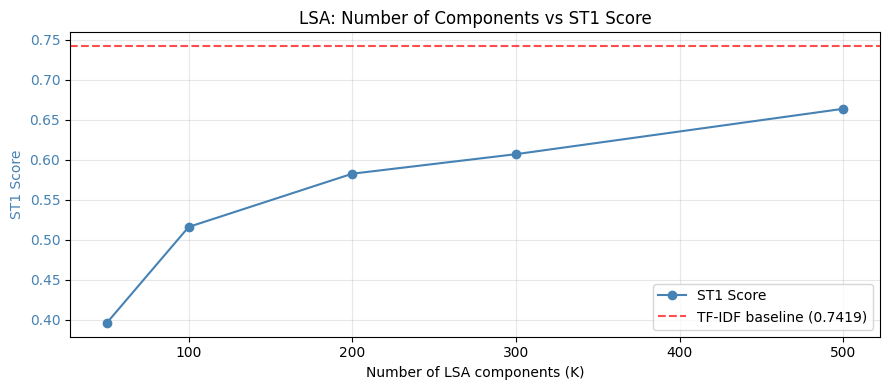

Αποθηκεύτηκε: lsa_k_vs_score.png


In [5]:
# Plot K vs Score
fig, ax1 = plt.subplots(figsize=(9, 4))

ax1.plot(k_values, scores_k, marker='o', color='steelblue', label='ST1 Score')
ax1.set_xlabel('Number of LSA components (K)')
ax1.set_ylabel('ST1 Score', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(y=0.7419, color='red', linestyle='--', alpha=0.7, label='TF-IDF baseline (0.7419)')
ax1.legend(loc='lower right')
ax1.set_title('LSA: Number of Components vs ST1 Score')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lsa_k_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: lsa_k_vs_score.png')

K vs Score curve: Το score συνεχίζει να ανεβαίνει μέχρι K=500 χωρίς να σταθεροποιείται — σημαίνει ότι χρειάζεσαι πολλές διαστάσεις για να αποτυπώσεις τη σημασιολογία του domain.

## 2. LSA Topic Visualization

Βλέπουμε ποιες λέξεις συνθέτουν τα πρώτα latent topics.

=== TOP 8 ΛΕΞΕΙΣ ΑΝΑ LATENT TOPIC (πρώτα 10) ===

Topic  1: products | recall | food | brand | recalled | product | inspection | distribution
Topic  2: distribution | brand | recalled | recall details | reason recall | reason | hazard classification | classification
Topic  3: cause | organism | elderly | elderly people | immune | systems | immune systems | infections
Topic  4: consumers | product | published | defects | pra | description | date published | product description
Topic  5: allergy alerts | recalls allergy | archive | food recalls | alerts | archive previously | safety status | reference research
Topic  6: milk | undeclared | risk | allergy | run | run risk | allergic | threatening
Topic  7: pack size | pack | size | batch | risk allergy | possible health | health risk | possible
Topic  8: number | recall notification | notification | domestic est | product foreign | fsis case | domestic | opened date
Topic  9: salmonella | salmonella organism | healthy persons | persons in

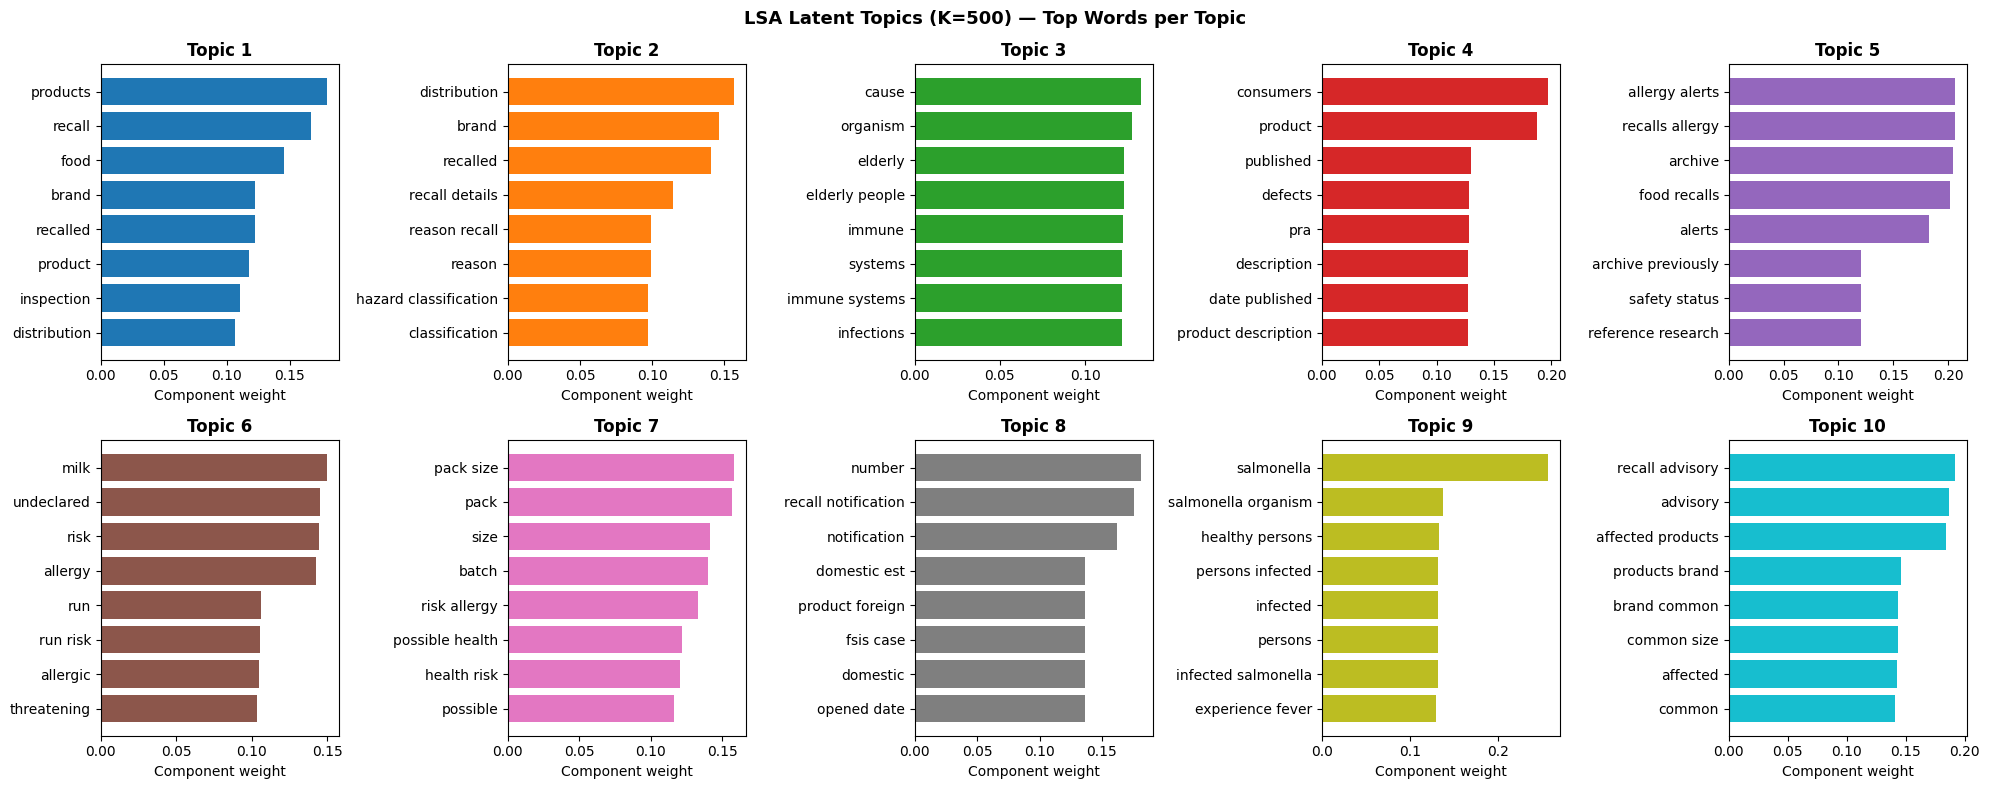

Αποθηκεύτηκε: lsa_topics.png


In [6]:
# Εκπαίδευση με βέλτιστο K
svd_best = TruncatedSVD(n_components=best_k, random_state=42)
svd_best.fit(X_train_tfidf)

feature_names = np.array(tfidf.get_feature_names_out())

# Top words ανά topic (πρώτα 10 topics)
n_top_words = 8
n_topics_show = min(10, best_k)

print(f'=== TOP {n_top_words} ΛΕΞΕΙΣ ΑΝΑ LATENT TOPIC (πρώτα {n_topics_show}) ===\n')
for topic_idx in range(n_topics_show):
    top_idx   = svd_best.components_[topic_idx].argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f'Topic {topic_idx+1:2d}: {" | ".join(top_words)}')

# Visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, n_topics_show))

for i in range(n_topics_show):
    top_idx    = svd_best.components_[i].argsort()[-n_top_words:][::-1]
    top_words  = [feature_names[j] for j in top_idx]
    top_scores = svd_best.components_[i][top_idx]
    axes[i].barh(top_words[::-1], top_scores[::-1], color=colors[i])
    axes[i].set_title(f'Topic {i+1}', fontweight='bold')
    axes[i].set_xlabel('Component weight')

plt.suptitle(f'LSA Latent Topics (K={best_k}) — Top Words per Topic',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lsa_topics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: lsa_topics.png')

Το LSA έχει ανακαλύψει meaningful semantic topics — αλλά τα χάνει όταν μειώνει διαστάσεις γιατί πολλές κλάσεις μοιράζονται κοινό vocabulary.

## 3. Τελικό Μοντέλο & Submission

In [7]:
print(f'=== ΤΕΛΙΚΟ ΜΟΝΤΕΛΟ LSA (K={best_k}) + SVM ===')

svd_final  = TruncatedSVD(n_components=best_k, random_state=42)
normalizer = Normalizer(norm='l2')

X_train_lsa = normalizer.fit_transform(svd_final.fit_transform(X_train_tfidf))
X_valid_lsa = normalizer.transform(svd_final.transform(X_valid_tfidf))
X_test_lsa  = normalizer.transform(svd_final.transform(X_test_tfidf))

clf_h = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
clf_h.fit(X_train_lsa, train['hazard-category'])
clf_p = LinearSVC(C=0.5, class_weight='balanced', max_iter=2000, random_state=42)
clf_p.fit(X_train_lsa, train['product-category'])

score_lsa = official_st1_score(
    valid['hazard-category'], clf_h.predict(X_valid_lsa),
    valid['product-category'], clf_p.predict(X_valid_lsa)
)

pd.DataFrame({
    'id': test['id'],
    'hazard-category':  clf_h.predict(X_test_lsa),
    'product-category': clf_p.predict(X_test_lsa)
}).to_csv('submission_lsa.csv', index=False)
print('\nΑποθηκεύτηκε: submission_lsa.csv')

print('\n=== ΣΥΓΚΡΙΣΗ ===')
print(f'BM25 + SVM:    0.7194')
print(f'TF-IDF + SVM:  0.7419  ← baseline')
print(f'LSA + SVM:     {score_lsa:.4f}')
print(f'DistilBERT:    0.7606')
print(f'Best model:    0.8188')

=== ΤΕΛΙΚΟ ΜΟΝΤΕΛΟ LSA (K=500) + SVM ===
  macro-F1 Hazard:                    0.7516
  Σωστά hazard:                       513/565 (90.8%)
  macro-F1 Product (given correct h): 0.5757
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OFFICIAL ST1 SCORE:                 0.6637

Αποθηκεύτηκε: submission_lsa.csv

=== ΣΥΓΚΡΙΣΗ ===
BM25 + SVM:    0.7194
TF-IDF + SVM:  0.7419  ← baseline
LSA + SVM:     0.6637
DistilBERT:    0.7606
Best model:    0.8188
